<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Homework%202/Econ_3916_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])


mean_latency = latency_logs.mean()
median_latency = np.median(latency_logs)
percentile_95 = np.percentile(latency_logs, 95)
percentile_99 = np.percentile(latency_logs, 99)

print("Mean Latency:", mean_latency, "MS")
print("Median Latency:", mean_latency, "MS")
print("95th Percentile Latency:", mean_latency, "MS")
print("99th Percentile Latency:", mean_latency, "MS")

def calculate_mad(data):
  median = np.median(data)
  absolute_deviations = np.abs(data - median)
  MAD = np.median(absolute_deviations)
  return MAD


std_dev = np.std(latency_logs)
print("Standard Deviation:", std_dev, "MS")

MAD_REAL = calculate_mad(latency_logs)
print("MAD:", MAD_REAL, "MS")


print("Standard Deviation is very sensitive to large outliers becuase it squares data while the MAD calculation"
"only uses medians which removes a lot of extremity. So the spikes in latency_logs cause the SD to explode "
"and square the numbers while the median for MAD just works around it.")




Mean Latency: 90.799 MS
Median Latency: 90.799 MS
95th Percentile Latency: 90.799 MS
99th Percentile Latency: 90.799 MS
Standard Deviation: 419.62864368272096 MS
MAD: 8.0 MS
Standard Deviation is very sensitive to large outliers becuase it squares data while the MAD calculationonly uses medians which removes a lot of extremity. So the spikes in latency_logs cause the SD to explode and square the numbers while the median for MAD just works around it.


In [13]:
def bayesian_audit(prior, sensitivity, specificity):
  noncheater = 1 - prior
  false_positive = 1 - specificity
  p_flagged = (sensitivity * prior) + (false_positive * noncheater)

  posterior_probaility = (sensitivity * prior) / p_flagged

  return posterior_probaility



senario_a = bayesian_audit(prior = .5, sensitivity = .98, specificity = .98)

print("P(Cheater | Flagged) = %.1f%%" % (senario_a * 100))


senario_b = bayesian_audit(prior = .05, sensitivity = .98, specificity = .98)

print("P(Cheater | Flagged) = %.1f%%" % (senario_b * 100))

senario_c = bayesian_audit(prior = .001, sensitivity = .98, specificity = .98)

print("P(Cheater | Flagged) = %.1f%%" % (senario_c * 100))



P(Cheater | Flagged) = 98.0%
P(Cheater | Flagged) = 72.1%
P(Cheater | Flagged) = 4.7%


In [14]:
observed = np.array([50250, 49750])

expected = np.array([50000, 50000])


chi_sq = 0

for i in range (len(observed)):
  difference = observed[i] - expected[i]
  difference_squared = difference * difference
  x = difference_squared / expected[i]
  chi_sq += x

print("Chi Squared:", chi_sq)

print("Experiment Valid: " + str(chi_sq <= 3.84))

print("App could have crashed")

Chi Squared: 2.5
Experiment Valid: True
App could have crashed


=== Crypto Survivorship Bias Simulation ===

Total tokens launched: 10,000
Mean Market Cap (All tokens): $2,740.84
Median Market Cap (All tokens): $1,571.78

Survivors (Top 1%): 100
Mean Market Cap (Survivors): $44,633.52
Median Market Cap (Survivors): $32,873.03

🚨 SURVIVORSHIP BIAS: 16.3x
Looking only at survivors makes the market look 16.3x better!


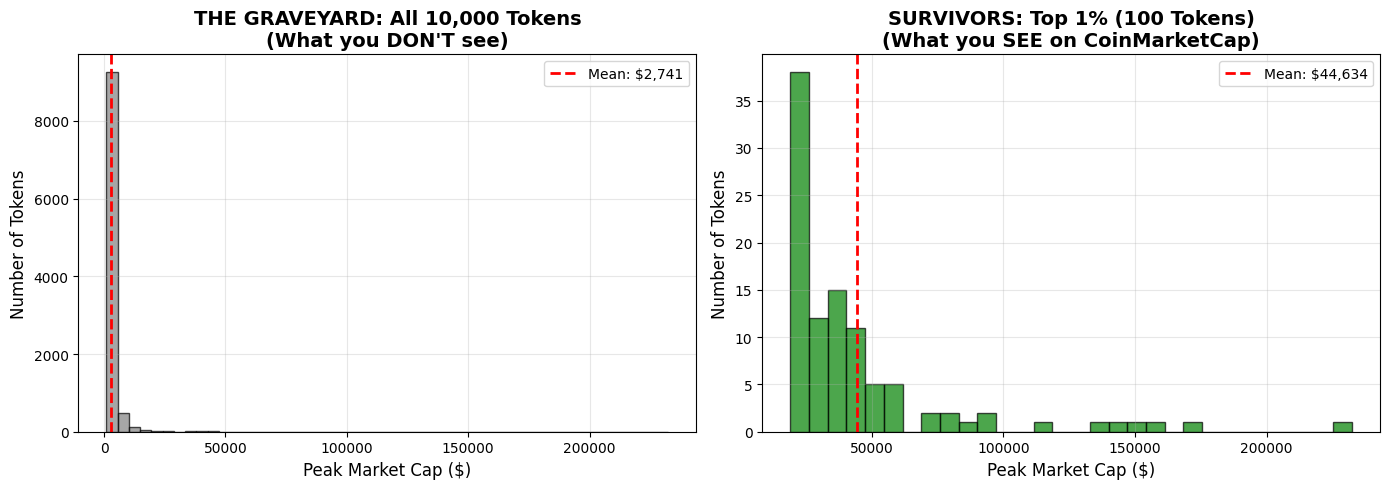


=== THE REALITY CHECK ===
Bottom 50% of tokens: $1,571.78 or less
Bottom 90% of tokens: $4,513.19 or less
Top 10% of tokens: $4,513.19 or more
Top 1% of tokens: $19,093.62 or more

Tokens with market cap < $5,000: 9,135 (91.3%)


In [15]:
# AI

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("=== Crypto Survivorship Bias Simulation ===\n")

# Step 1: Simulate 10,000 token launches with Pareto Distribution
n_tokens = 10000

# Pareto distribution (Power Law): shape parameter determines inequality
# Higher shape = more extreme inequality (most tokens near zero)
shape = 1.5  # This creates extreme inequality
scale = 1000  # Base scale in dollars

# Generate market caps using Pareto distribution
# Most tokens will be near zero, few will be huge
peak_market_caps = (np.random.pareto(shape, n_tokens) + 1) * scale

# Step 2: Create "The Graveyard" - All tokens
df_all = pd.DataFrame({
    'token_id': range(1, n_tokens + 1),
    'peak_market_cap': peak_market_caps
})

print(f"Total tokens launched: {len(df_all):,}")
print(f"Mean Market Cap (All tokens): ${df_all['peak_market_cap'].mean():,.2f}")
print(f"Median Market Cap (All tokens): ${df_all['peak_market_cap'].median():,.2f}")

# Step 3: Create "Survivors" - Top 1% only
# These are the tokens you see on CoinMarketCap, in the news, etc.
top_1_percent = int(n_tokens * 0.01)
df_survivors = df_all.nlargest(top_1_percent, 'peak_market_cap')

print(f"\nSurvivors (Top 1%): {len(df_survivors):,}")
print(f"Mean Market Cap (Survivors): ${df_survivors['peak_market_cap'].mean():,.2f}")
print(f"Median Market Cap (Survivors): ${df_survivors['peak_market_cap'].median():,.2f}")

# Step 4: Calculate the Survivorship Bias
bias_multiplier = df_survivors['peak_market_cap'].mean() / df_all['peak_market_cap'].mean()
print(f"\n🚨 SURVIVORSHIP BIAS: {bias_multiplier:.1f}x")
print(f"Looking only at survivors makes the market look {bias_multiplier:.1f}x better!")

# Step 5: Visualization - Dual Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: The Graveyard (All tokens)
axes[0].hist(df_all['peak_market_cap'], bins=50, color='gray', alpha=0.7, edgecolor='black')
axes[0].axvline(df_all['peak_market_cap'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: ${df_all['peak_market_cap'].mean():,.0f}")
axes[0].set_xlabel('Peak Market Cap ($)', fontsize=12)
axes[0].set_ylabel('Number of Tokens', fontsize=12)
axes[0].set_title('THE GRAVEYARD: All 10,000 Tokens\n(What you DON\'T see)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot: Survivors (Top 1%)
axes[1].hist(df_survivors['peak_market_cap'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(df_survivors['peak_market_cap'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: ${df_survivors['peak_market_cap'].mean():,.0f}")
axes[1].set_xlabel('Peak Market Cap ($)', fontsize=12)
axes[1].set_ylabel('Number of Tokens', fontsize=12)
axes[1].set_title('SURVIVORS: Top 1% (100 Tokens)\n(What you SEE on CoinMarketCap)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Additional Analysis - The Reality Check
print("\n=== THE REALITY CHECK ===")
print(f"Bottom 50% of tokens: ${df_all['peak_market_cap'].quantile(0.50):,.2f} or less")
print(f"Bottom 90% of tokens: ${df_all['peak_market_cap'].quantile(0.90):,.2f} or less")
print(f"Top 10% of tokens: ${df_all['peak_market_cap'].quantile(0.90):,.2f} or more")
print(f"Top 1% of tokens: ${df_all['peak_market_cap'].quantile(0.99):,.2f} or more")

# What percentage of tokens are essentially worthless?
worthless_threshold = 5000  # Less than $5k market cap
worthless_count = (df_all['peak_market_cap'] < worthless_threshold).sum()
worthless_pct = (worthless_count / len(df_all)) * 100

print(f"\nTokens with market cap < ${worthless_threshold:,}: {worthless_count:,} ({worthless_pct:.1f}%)")